In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
from pathlib import Path

csv_name = "household_data_15min_singleindex.csv"

csv_path = None
for root in [Path.cwd(), *Path.cwd().parents]:
	candidate = root / "data" / csv_name
	if candidate.exists():
		csv_path = candidate
		break

if csv_path is None:
	raise FileNotFoundError(f"Could not find {csv_name} in the current folder or any parent folder.")

df = pd.read_csv(csv_path)
df.head()

,utc_timestamp,cet_cest_timestamp,DE_KN_industrial1_grid_import,DE_KN_industrial1_pv_1,DE_KN_industrial1_pv_2,DE_KN_industrial2_grid_import,DE_KN_industrial2_pv,DE_KN_industrial2_storage_charge,DE_KN_industrial2_storage_decharge,DE_KN_industrial3_area_offices,...,DE_KN_residential5_refrigerator,DE_KN_residential5_washing_machine,DE_KN_residential6_circulation_pump,DE_KN_residential6_dishwasher,DE_KN_residential6_freezer,DE_KN_residential6_grid_export,DE_KN_residential6_grid_import,DE_KN_residential6_pv,DE_KN_residential6_washing_machine,interpolated
0,2014-12-11T17:45:00Z,2014-12-11T18:45:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-12-11T18:00:00Z,2014-12-11T19:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-12-11T18:15:00Z,2014-12-11T19:15:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014-12-11T18:30:00Z,2014-12-11T19:30:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-12-11T18:45:00Z,2014-12-11T19:45:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing values

In [17]:
pd.set_option('display.max_rows', None)

missing_pct = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)
print(missing_pct)

DE_KN_public2_grid_import              97.08
DE_KN_public1_grid_import              88.17
DE_KN_industrial2_storage_charge       74.64
DE_KN_industrial2_storage_decharge     74.64
DE_KN_residential2_freezer             73.34
DE_KN_industrial3_ev                   72.88
DE_KN_residential4_refrigerator        72.01
DE_KN_industrial2_grid_import          70.67
DE_KN_industrial3_grid_import          70.07
DE_KN_residential3_grid_import         69.04
DE_KN_industrial2_pv                   68.79
DE_KN_residential4_washing_machine     68.12
DE_KN_residential4_heat_pump           67.99
DE_KN_residential4_dishwasher          67.18
DE_KN_residential1_freezer             66.47
DE_KN_residential6_dishwasher          63.43
DE_KN_industrial3_refrigerator         62.95
DE_KN_industrial3_machine_3            62.66
DE_KN_industrial3_dishwasher           62.66
DE_KN_industrial3_pv_roof              62.66
DE_KN_industrial3_machine_2            62.66
DE_KN_industrial3_machine_1            62.66
DE_KN_indu

Residential 3 the best out of all, having all appliance with around 20% of missing data. Only grid_import has 69% of missing data which is not that good

Now checking if its one continuos block of missing values

In [18]:
s = df['DE_KN_residential3_grid_import']
mask = s.notnull()
groups = (mask != mask.shift()).cumsum()
valid_windows = df[mask].groupby(groups[mask]).agg({
    'utc_timestamp': ['min', 'max', 'count']
})
valid_windows.columns = ['start', 'end', 'length']
valid_windows = valid_windows.sort_values('length', ascending=False)

print(valid_windows.head())

                                               start                   end  \
DE_KN_residential3_grid_import                                               
2                               2016-02-28T17:15:00Z  2017-07-08T16:00:00Z   

                                length  
DE_KN_residential3_grid_import          
2                                47612  


Missing data is not scattered but one continuous window from From 2016-02-28 → 2017-07-08  of 1.36 years

In [19]:
cols = [col for col in df.columns if "DE_KN_residential3" in col]
cols = ["utc_timestamp"] + cols

df_r3 = df[cols].copy()

In [20]:
df_r3 = df_r3[
    (df_r3["utc_timestamp"] >= "2016-02-28T17:15:00Z") &
    (df_r3["utc_timestamp"] <= "2017-07-08T16:00:00Z")
].copy()

convert to datetime object

In [21]:
df_r3["utc_timestamp"] = pd.to_datetime(df_r3["utc_timestamp"])
df_r3 = df_r3.sort_values("utc_timestamp")
df_r3 = df_r3.set_index("utc_timestamp")

converting cumulative energy to enery usage per timeframe

In [ ]:
df_usage = df_r3.diff().copy()
df_usage = df_usage.dropna()
df_usage[df_usage < 0] = 0

In [ ]:
df_usage.describe()

,DE_KN_residential3_circulation_pump,DE_KN_residential3_dishwasher,DE_KN_residential3_freezer,DE_KN_residential3_grid_export,DE_KN_residential3_grid_import,DE_KN_residential3_pv,DE_KN_residential3_refrigerator,DE_KN_residential3_washing_machine
count,47611.000000,47611.000000,47611.000000,47611.000000,47611.000000,47611.000000,47611.000000,47611.000000
mean,0.014032,0.008371,0.003219,0.099343,0.121360,0.152817,0.006144,0.014764
std,0.007694,0.044632,0.007381,0.189538,3.686171,0.793327,0.005391,0.060907
min,0.001000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.007000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.016000,0.001000,0.000000,0.000000,0.060000,0.000000,0.006000,0.000000
75%,0.018000,0.001000,0.001000,0.100000,0.151000,0.206000,0.012000,0.000000
max,0.036000,0.446000,0.036000,0.950000,803.940000,73.306000,0.017000,0.522000


In [29]:
idx = df_usage["DE_KN_residential3_grid_import"].idxmax()

df_r3.loc[idx - pd.Timedelta(minutes=30): idx + pd.Timedelta(minutes=30),
          "DE_KN_residential3_grid_import"]

utc_timestamp
2017-01-05 16:30:00+00:00    3160.015
2017-01-05 16:45:00+00:00    3160.690
2017-01-05 17:00:00+00:00    3161.970
2017-01-05 17:15:00+00:00    3162.425
2017-01-05 17:30:00+00:00    3162.810
Name: DE_KN_residential3_grid_import, dtype: float64

removing impossible values. 10 Kwh is already suspicious for a residential household for 15 minute interval

In [28]:
df_usage = df_usage[
    df_usage["DE_KN_residential3_grid_import"] < 10
]
df_usage.describe()

,DE_KN_residential3_circulation_pump,DE_KN_residential3_dishwasher,DE_KN_residential3_freezer,DE_KN_residential3_grid_export,DE_KN_residential3_grid_import,DE_KN_residential3_pv,DE_KN_residential3_refrigerator,DE_KN_residential3_washing_machine
count,47610.000000,47610.000000,47610.000000,47610.000000,47610.000000,47610.000000,47610.000000,47610.000000
mean,0.014032,0.008371,0.003219,0.099345,0.104477,0.152820,0.006144,0.014764
std,0.007694,0.044632,0.007381,0.189539,0.127981,0.793335,0.005391,0.060908
min,0.001000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.007000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.016000,0.001000,0.000000,0.000000,0.060000,0.000000,0.006000,0.000000
75%,0.018000,0.001000,0.001000,0.100000,0.151000,0.206000,0.012000,0.000000
max,0.036000,0.446000,0.036000,0.950000,1.280000,73.306000,0.017000,0.522000


Plots

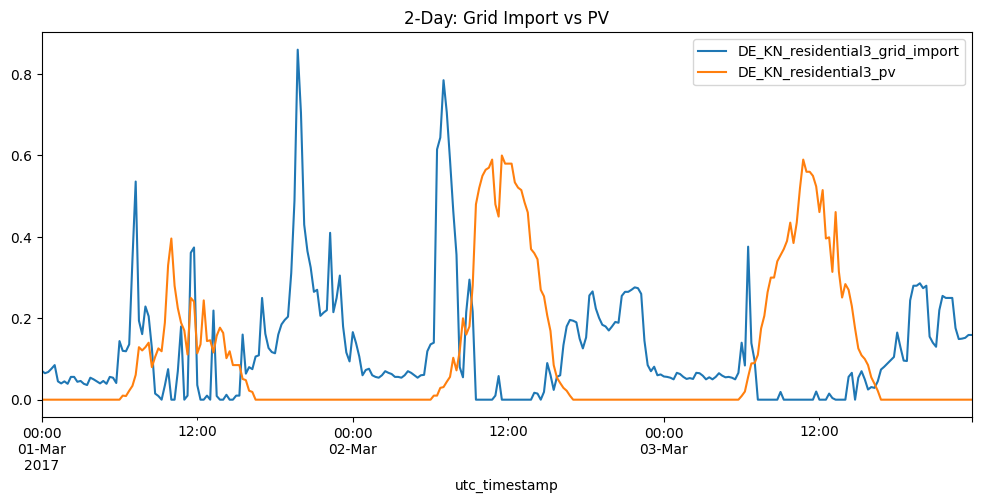

In [31]:
df_usage.loc["2017-03-01":"2017-03-03",
             ['DE_KN_residential3_grid_import',
              'DE_KN_residential3_pv']].plot(figsize=(12,5))
plt.title("2-Day: Grid Import vs PV")
plt.show()

This plot shows the short-term interaction between solar generation and grid electricity usage. PV generation follows a clear daily pattern, with zero output during nighttime and peaks during midday. Grid import, however, fluctuates independently with several spikes. While there are periods where grid import decreases during high PV generation, the relationship is weak, indicating that the household does not consistently utilize solar energy to reduce grid dependency.

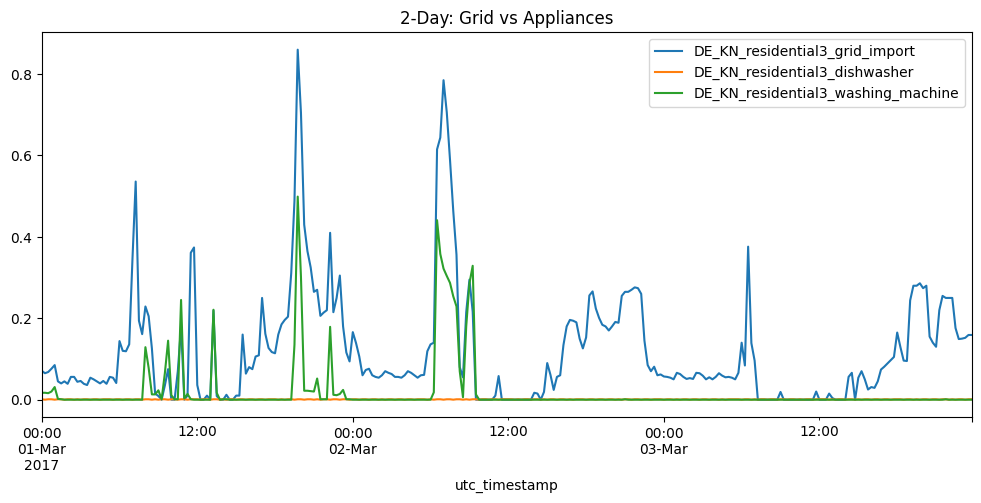

In [32]:
df_usage.loc["2017-03-01":"2017-03-03",
             ['DE_KN_residential3_grid_import',
              'DE_KN_residential3_dishwasher',
              'DE_KN_residential3_washing_machine']].plot(figsize=(12,5))
plt.title("2-Day: Grid vs Appliances")
plt.show()

This plot highlights the impact of individual appliances on total electricity consumption. Peaks in grid import often coincide with spikes in appliance usage, particularly the washing machine, indicating that such devices significantly contribute to short-term demand increases. The dishwasher appears less frequently, suggesting lower usage or weaker influence. Overall, appliance usage drives consumption variability.

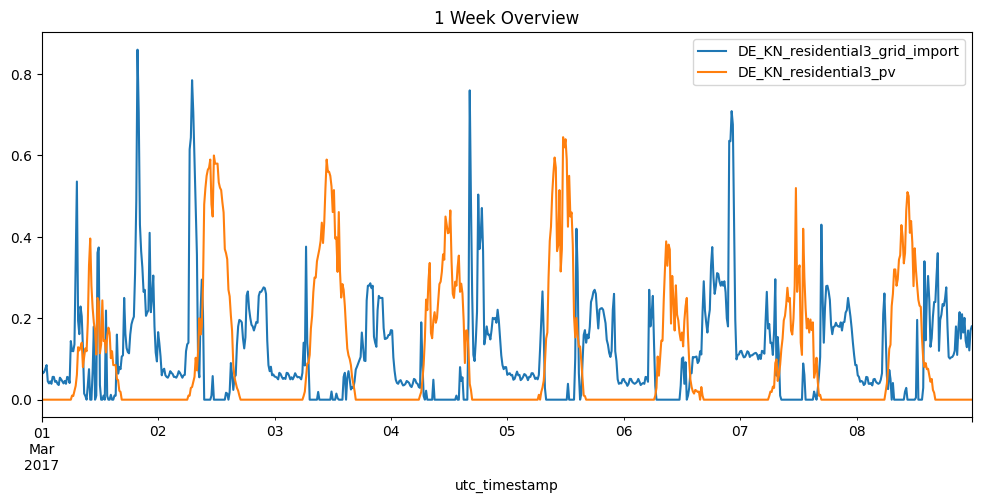

In [33]:
df_usage.loc["2017-03-01":"2017-03-08",
             ['DE_KN_residential3_grid_import',
              'DE_KN_residential3_pv']].plot(figsize=(12,5))
plt.title("1 Week Overview")
plt.show()

The weekly view provides a broader perspective on energy patterns. PV generation shows a consistent daily cycle, while grid import varies irregularly without a clear weekly trend. This suggests that solar generation is predictable, whereas electricity consumption is largely influenced by user behavior rather than repeating weekly patterns.

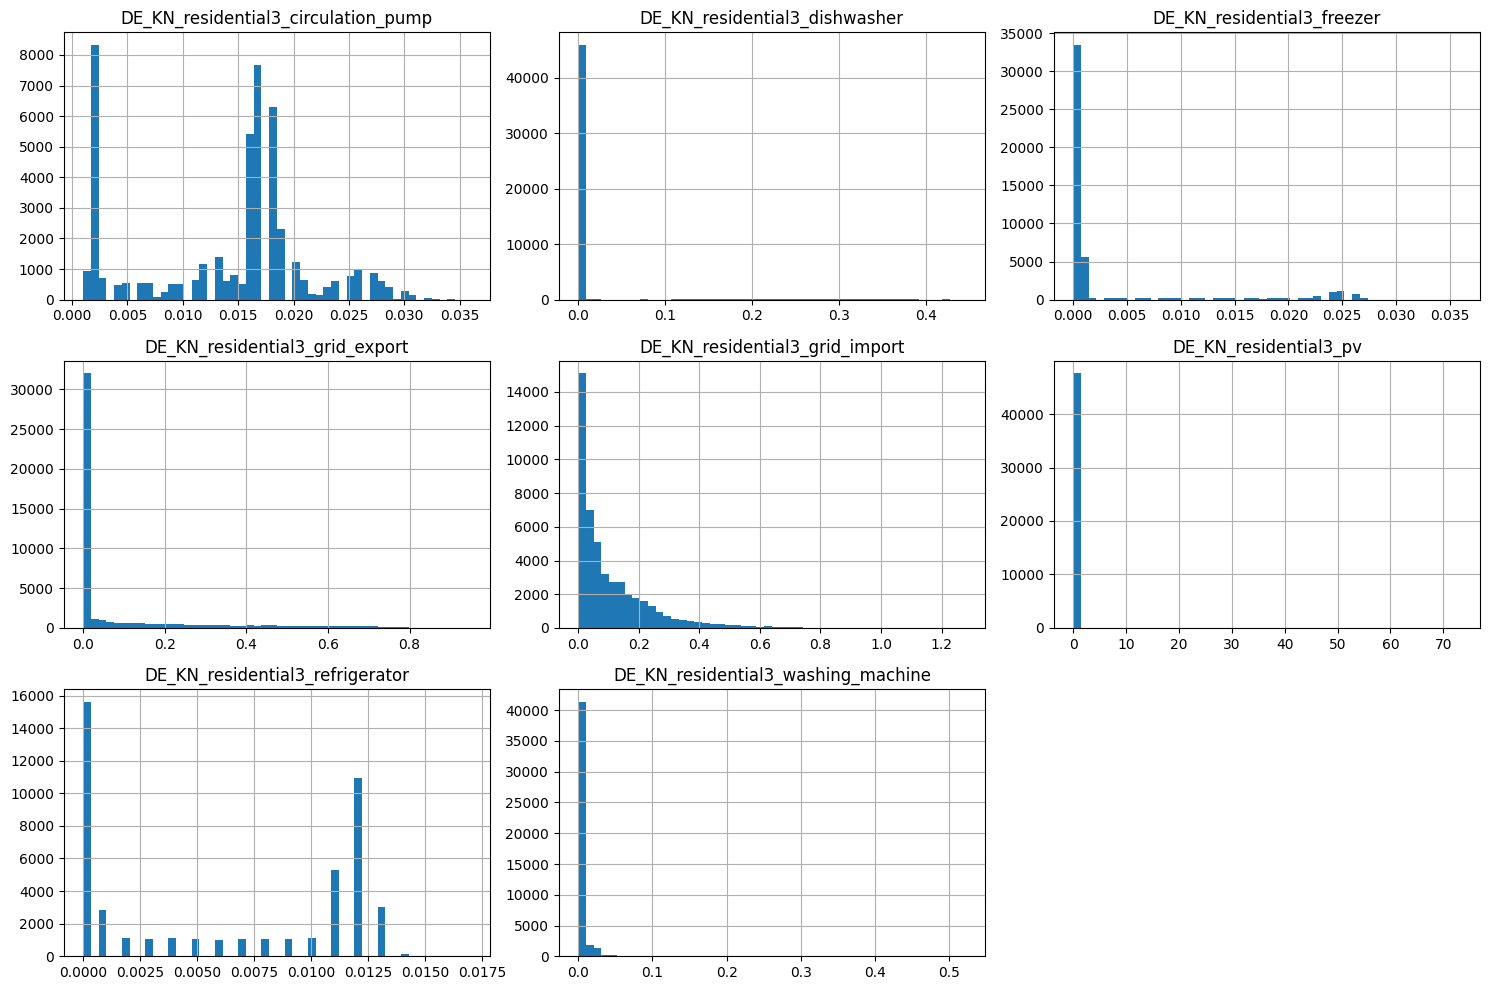

In [34]:
df_usage.hist(figsize=(15,10), bins=50)
plt.tight_layout()
plt.show()

The distributions reveal different usage behaviors across variables. Grid import is right-skewed, with many low values and occasional peaks, reflecting baseline consumption with sporadic high demand. PV generation shows a large concentration at zero, corresponding to nighttime periods, and higher values during the day. Appliances such as the washing machine and dishwasher are mostly inactive with occasional spikes, indicating event-based usage, while devices like refrigerators and pumps exhibit stable, low-level consumption.

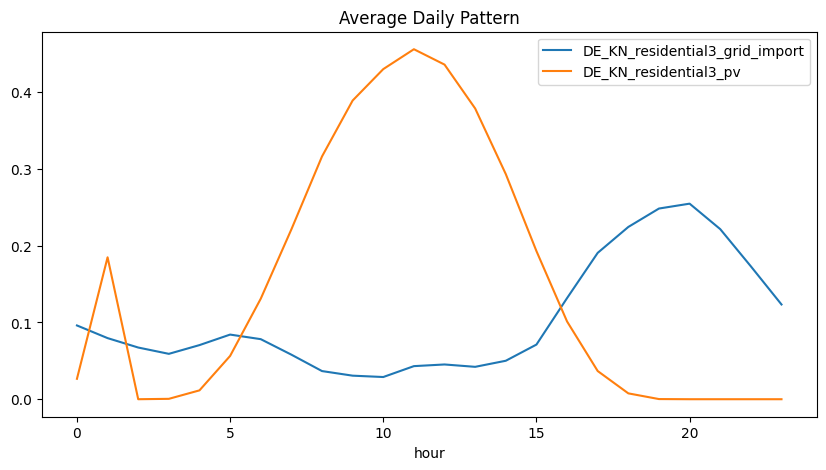

In [35]:
df_usage['hour'] = df_usage.index.hour

daily_pattern = df_usage.groupby('hour').mean()

daily_pattern[['DE_KN_residential3_grid_import',
               'DE_KN_residential3_pv']].plot(figsize=(10,5))
plt.title("Average Daily Pattern")
plt.show()

This plot shows the average behavior over a typical day. PV generation peaks around midday, while grid import reaches its highest levels in the evening. This clear mismatch indicates that energy is generated when it is not needed most, leading to continued reliance on grid electricity. The pattern highlights inefficiencies in energy usage and suggests potential for optimization.

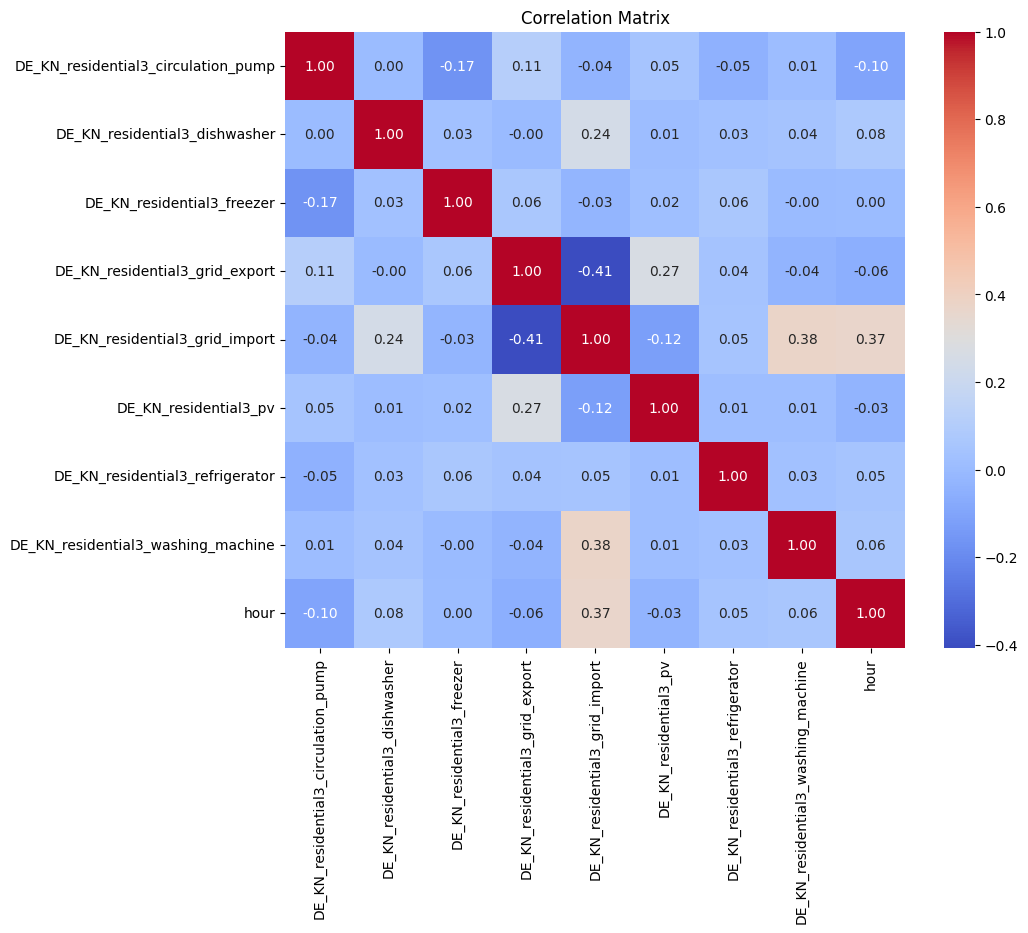

In [36]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df_usage.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

The correlation analysis shows relationships between variables. Grid import has moderate positive correlations with the washing machine and time of day, indicating that both appliance usage and daily routines influence electricity demand. A negative correlation between grid import and grid export reflects the effect of solar generation. However, the weak correlation between PV and grid import suggests that solar energy is not strongly reducing grid consumption.

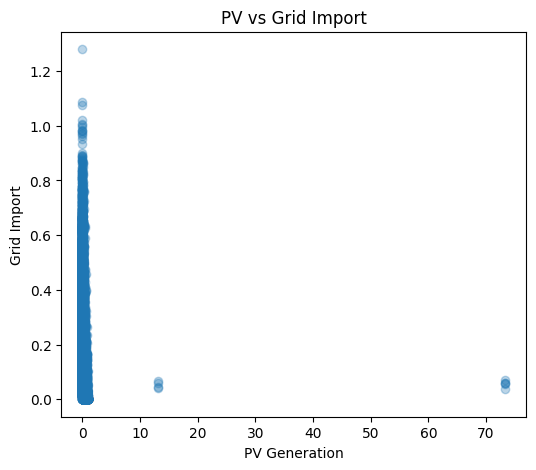

In [37]:
plt.figure(figsize=(6,5))
plt.scatter(df_usage['DE_KN_residential3_pv'],
            df_usage['DE_KN_residential3_grid_import'],
            alpha=0.3)
plt.xlabel("PV Generation")
plt.ylabel("Grid Import")
plt.title("PV vs Grid Import")
plt.show()

This scatter plot illustrates the relationship between solar generation and grid usage. Most observations occur when PV generation is zero, representing nighttime. For periods with solar output, there is no strong inverse relationship with grid import. This confirms that higher solar generation does not consistently lead to lower grid consumption, indicating limited integration of renewable energy into household usage patterns.